# Modelagem

Neste estágio, reconstruímos a trilha de **Classificação Hierárquica** (Primeiro 'Classe Macro', Depois 'Classe Detalhada')

A trilha **linear** adotada será:
1. **O Cenário Negativo (Com Duplicatas):** Testaremos os dados brutos e apontaremos o problema do **Data Leakage**.
2. **Realidade do Negócio vs Avaliação Cega:** Treinaremos o modelo com duplicatas reais, mas validaremos em uma base blindada e inédita.
3. **Avaliação Rigorosa e Simulação:** Cruzamento dos algoritmos, métricas sem erro e uma Sandbox final para testes dinâmicos.


## 1. Importação de Dependências em Nível de Produção


In [140]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, f1_score, accuracy_score
import joblib
import warnings

warnings.filterwarnings('ignore')


## 2. ETAPA 1: Data Leakage
O erro é cruzar os dados brutos. Como os chamados se repetem, o modelo apenas replica no teste o que aprendeu no treino.


In [141]:
df_full = pd.read_pickle('data/dataset_processed.pkl')
print(f"Volume Bruto de Chamados recebidos: {len(df_full)}")

X_full = df_full['texto_spacy']
y_macro_full = df_full['classe_macro']
y_det_full = df_full['classe_detalhada']

X_train_f, X_test_f, ym_train_f, ym_test_f, yd_train_f, yd_test_f = train_test_split(
    X_full, y_macro_full, y_det_full, test_size=0.25, random_state=42, stratify=y_det_full
)

print(f"Linhas Treino com Duplicatas: {len(X_train_f)}")
print(f"Linhas Teste com Duplicatas: {len(X_test_f)}")


Volume Bruto de Chamados recebidos: 1200
Linhas Treino com Duplicatas: 900
Linhas Teste com Duplicatas: 300


In [142]:
pipe_overfit_macro = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LinearSVC(random_state=42))
])
pipe_overfit_macro.fit(X_train_f, ym_train_f)
preds_f = pipe_overfit_macro.predict(X_test_f)


print(classification_report(ym_test_f, preds_f))


                           precision    recall  f1-score   support

   Feedback e Experiência       1.00      1.00      1.00        59
    Financeiro e Cobrança       1.00      1.00      1.00        59
                   Outros       1.00      1.00      1.00        63
       Problemas Técnicos       1.00      1.00      1.00        58
Solicitações Operacionais       1.00      1.00      1.00        61

                 accuracy                           1.00       300
                macro avg       1.00      1.00      1.00       300
             weighted avg       1.00      1.00      1.00       300



In [143]:
pipe_overfit_det = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LinearSVC(random_state=42))
])
pipe_overfit_det.fit(X_train_f, yd_train_f)
preds_det = pipe_overfit_det.predict(X_test_f)


print(classification_report(yd_test_f, preds_det))

                                        precision    recall  f1-score   support

                 Agradecimento Simples       1.00      1.00      1.00        21
         Alteração de Plano / Contrato       1.00      1.00      1.00         9
                 Atualização Cadastral       1.00      1.00      1.00        10
         Cobrança Indevida / Duplicada       1.00      1.00      1.00        11
          Criação / Gestão de Usuários       1.00      1.00      1.00         9
                Crítica de Usabilidade       1.00      1.00      1.00        19
            Customização de Relatórios       1.00      1.00      1.00         7
        Dúvidas sobre Fatura / Valores       1.00      1.00      1.00         9
         Erro de Autenticação e Acesso       1.00      1.00      1.00        10
       Erro de Exportação / Relatórios       1.00      1.00      1.00        10
           Erro de Sistema / Aplicação       1.00      1.00      1.00        11
               Falha de Banco de Dados 

## 3. ETAPA 2: Removendo as duplicatas
Aqui separamos os textos ÚNICOS primeiro. Garantindo que o Treinamento carregue a realidade das duplicatas do dia a dia, mas a Validação final será composta de casos ÚNICOS que o modelo  ainda não viu.


In [144]:
textos_unicos = df_full['texto_spacy'].unique()

In [145]:
train_txt, test_txt = train_test_split(textos_unicos, test_size=0.4, random_state=42)

df_train = df_full[df_full['texto_spacy'].isin(train_txt)].copy()
df_test = df_full[df_full['texto_spacy'].isin(test_txt)].drop_duplicates(subset='texto_spacy').copy()

In [146]:
# Treino (Volume da realidade do negócio)
X_train_text = df_train['texto_spacy']
X_train_dense = np.stack(df_train['embedding'].values) 
y_train_mac = df_train['classe_macro']
y_train_det = df_train['classe_detalhada']

# Teste (Totalmente blindado)
X_test_text = df_test['texto_spacy']
X_test_dense = np.stack(df_test['embedding'].values)
y_test_mac = df_test['classe_macro']
y_test_det = df_test['classe_detalhada']

print(f"📊 Treino Frequencial: {len(df_train)} ocorrências totais (com duplicatas da vida real)")
print(f"🎯 Teste Cego: {len(df_test)} chamados")

📊 Treino Frequencial: 698 ocorrências totais (com duplicatas da vida real)
🎯 Teste Cego: 32 chamados


In [147]:
pipe_macro = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LinearSVC(random_state=42))
])
pipe_macro.fit(X_train_text, y_train_mac)
preds_macro = pipe_macro.predict(X_test_text)


print(classification_report(y_test_mac, preds_macro))


                           precision    recall  f1-score   support

   Feedback e Experiência       0.33      0.25      0.29         4
    Financeiro e Cobrança       0.80      0.50      0.62         8
                   Outros       0.50      0.25      0.33         4
       Problemas Técnicos       1.00      0.50      0.67        10
Solicitações Operacionais       0.29      0.83      0.43         6

                 accuracy                           0.50        32
                macro avg       0.59      0.47      0.47        32
             weighted avg       0.67      0.50      0.52        32



In [148]:
pipe_det = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LinearSVC(random_state=42))
])
pipe_det.fit(X_train_text, y_train_det)
preds_det = pipe_det.predict(X_test_text)


print(classification_report(y_test_det, preds_det))

                                        precision    recall  f1-score   support

                 Agradecimento Simples       0.25      1.00      0.40         1
         Alteração de Plano / Contrato       0.25      1.00      0.40         1
                 Atualização Cadastral       0.00      0.00      0.00         1
         Cobrança Indevida / Duplicada       0.00      0.00      0.00         1
          Criação / Gestão de Usuários       0.00      0.00      0.00         1
                Crítica de Usabilidade       0.00      0.00      0.00         2
            Customização de Relatórios       0.40      1.00      0.57         2
        Dúvidas sobre Fatura / Valores       0.00      0.00      0.00         1
         Erro de Autenticação e Acesso       0.00      0.00      0.00         1
       Erro de Exportação / Relatórios       0.00      0.00      0.00         3
           Erro de Sistema / Aplicação       0.00      0.00      0.00         1
               Falha de Banco de Dados 

## 4. Cross-Validation 
Sem duplicatas no treino e sem duplicatas no teste.


In [149]:
cenarios = [
    ('Macro', y_train_mac, y_test_mac),
    ('Detalhada', y_train_det, y_test_det)
]

# Modelos para Features Esparsas (TF-IDF)
modelos_esparsos = {
    'Linear SVC': Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', LinearSVC(random_state=42))]),
    'Logistic Regression': Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', LogisticRegression(random_state=42, max_iter=1000))]),
    'Naive Bayes': Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', MultinomialNB())])
}

# Modelos para Features Densas (Embeddings)
modelos_densos = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression (Emb)': LogisticRegression(random_state=42, max_iter=1000)
}


In [150]:
resultados_finais = []

for label, y_train, y_test in cenarios:
    
    # 1. Testando Modelos baseados em Texto (TF-IDF)
    for nome, pipe in modelos_esparsos.items():
        pipe.fit(X_train_text, y_train)
        preds = pipe.predict(X_test_text)
        
        resultados_finais.append({
            'Alvo': label, 'Feature': 'TF-IDF', 'Modelo': nome,
            'Acurácia Real': accuracy_score(y_test, preds),
            'F1-Score Real': f1_score(y_test, preds, average='weighted')
        })
        
    # 2. Testando Modelos baseados em Embeddings (Densos)
    for nome, clf in modelos_densos.items():
        clf.fit(X_train_dense, y_train)
        preds = clf.predict(X_test_dense)
        
        resultados_finais.append({
            'Alvo': label, 'Feature': 'Embedding', 'Modelo': nome,
            'Acurácia Real': accuracy_score(y_test, preds),
            'F1-Score Real': f1_score(y_test, preds, average='weighted')
        })

In [151]:
df_torneio = pd.DataFrame(resultados_finais).sort_values(by=['Alvo', 'F1-Score Real'], ascending=[True, False])
display(df_torneio)

,Alvo,Feature,Modelo,Acurácia Real,F1-Score Real
5,Detalhada,TF-IDF,Linear SVC,0.31250,0.248214
9,Detalhada,Embedding,Logistic Regression (Emb),0.18750,0.134375
7,Detalhada,TF-IDF,Naive Bayes,0.15625,0.127083
6,Detalhada,TF-IDF,Logistic Regression,0.12500,0.114583
8,Detalhada,Embedding,Random Forest,0.12500,0.085417
4,Macro,Embedding,Logistic Regression (Emb),0.78125,0.784436
3,Macro,Embedding,Random Forest,0.65625,0.654886
0,Macro,TF-IDF,Linear SVC,0.50000,0.521082
1,Macro,TF-IDF,Logistic Regression,0.46875,0.487924
2,Macro,TF-IDF,Naive Bayes,0.43750,0.447630


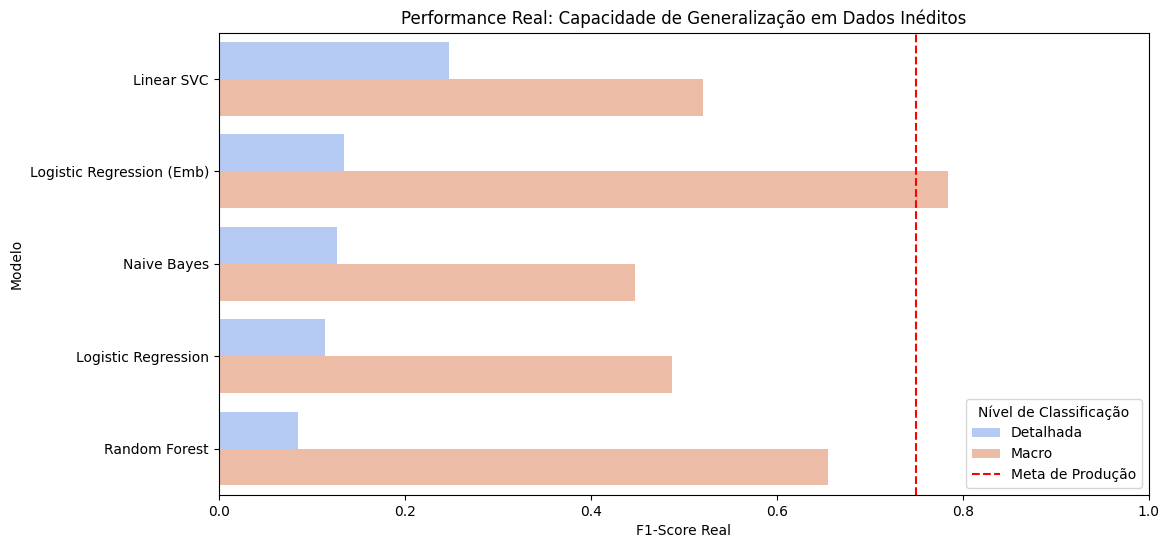

In [152]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_torneio, x='F1-Score Real', y='Modelo', hue='Alvo', palette='coolwarm')
plt.title('Performance Real: Capacidade de Generalização em Dados Inéditos')
plt.xlim(0, 1.0)
plt.axvline(0.75, color='red', linestyle='--', label='Meta de Produção')
plt.legend(title='Nível de Classificação', loc='lower right')
plt.show()

## Random search

In [153]:
param_grids = {
    'Linear SVC': {
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'tfidf__max_features': [1000, 3000, 5000],
        'clf__C': [0.1, 1, 10],
    },
    'Logistic Regression': {
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'clf__C': [0.1, 1, 10]
    },
    'Random Forest (Densa)': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    },
    'Logistic Regression (Emb)': {
        'C': [0.1, 1, 10]
    }
}

In [154]:
# 1. Definição Sincronizada (Rode esta célula primeiro)
modelos_esparsos = {
    'Linear SVC': Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', LinearSVC(random_state=42))]),
    'Logistic Regression': Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', LogisticRegression(random_state=42, max_iter=1000))]),
    'Naive Bayes': Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', MultinomialNB())])
}

modelos_densos = {
    'Random Forest (Densa)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression (Emb)': LogisticRegression(random_state=42, max_iter=1000)
}

# 2. Loop de Busca Protegido
ranking_tuning = []

for label, y_train, y_test in cenarios:
    print(f"🔎 Otimizando modelos para a Categoria: {label}...")
    
    for nome, grid in param_grids.items():
        # Verificação robusta para evitar o KeyError
        if nome in modelos_densos:
            base_model = modelos_densos[nome]
            X_search, X_eval = X_train_dense, X_test_dense
        elif nome in modelos_esparsos:
            base_model = modelos_esparsos[nome]
            X_search, X_eval = X_train_text, X_test_text
        else:
            print(f"⚠️ Modelo '{nome}' ignorado (não encontrado nos dicionários).")
            continue
            
        search = RandomizedSearchCV(
            base_model, grid, n_iter=5, cv=3, 
            scoring='f1_weighted', n_jobs=-1, random_state=42
        )
        
        search.fit(X_search, y_train)
        
        # Validação no Lote Blindado
        best_model = search.best_estimator_
        preds = best_model.predict(X_eval)
        
        ranking_tuning.append({
            'Alvo': label, 'Modelo': nome,
            'Acurácia Real': accuracy_score(y_test, preds),
            'F1-Score Real': f1_score(y_test, preds, average='weighted'),
            'Melhores Hiperparâmetros': str(search.best_params_)
        })
pd.set_option('display.max_colwidth', None)
df_ranking = pd.DataFrame(ranking_tuning).sort_values(by=['Alvo', 'F1-Score Real'], ascending=[True, False])
display(df_ranking)

🔎 Otimizando modelos para a Categoria: Macro...
🔎 Otimizando modelos para a Categoria: Detalhada...


,Alvo,Modelo,Acurácia Real,F1-Score Real,Melhores Hiperparâmetros
4,Detalhada,Linear SVC,0.28125,0.231250,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 1000, 'clf__C': 0.1}"
7,Detalhada,Logistic Regression (Emb),0.15625,0.118750,{'C': 0.1}
5,Detalhada,Logistic Regression,0.12500,0.114583,"{'tfidf__ngram_range': (1, 2), 'clf__C': 10}"
6,Detalhada,Random Forest (Densa),0.12500,0.085417,"{'n_estimators': 100, 'max_depth': None}"
3,Macro,Logistic Regression (Emb),0.78125,0.779067,{'C': 0.1}
2,Macro,Random Forest (Densa),0.65625,0.654886,"{'n_estimators': 100, 'max_depth': None}"
0,Macro,Linear SVC,0.50000,0.521082,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 1000, 'clf__C': 0.1}"
1,Macro,Logistic Regression,0.46875,0.474817,"{'tfidf__ngram_range': (1, 2), 'clf__C': 10}"


## 5. Grau de Confiança Probabilística (cada modelo)

In [155]:
modelo_macro_probs = LogisticRegression(C=0.1, random_state=42, max_iter=1000)

modelo_macro_probs.fit(X_train_dense, y_train_mac)

probs_mac = modelo_macro_probs.predict_proba(X_test_dense)
classes_mac = modelo_macro_probs.classes_

df_macro_conf = pd.DataFrame(probs_mac[:5], columns=classes_mac)
df_macro_conf['TEXTO (Amostra)'] = [str(x) for x in X_test_text.iloc[:5].values]
df_macro_conf['PREDIÇÃO MACRO'] = modelo_macro_probs.predict(X_test_dense[:5])
df_macro_conf['CONFIANÇA (%)'] = df_macro_conf[classes_mac].max(axis=1) * 100

print(" ANÁLISE DE CONFIANÇA:  MACRO")
display(df_macro_conf[['TEXTO (Amostra)', 'PREDIÇÃO MACRO', 'CONFIANÇA (%)']])

 ANÁLISE DE CONFIANÇA:  MACRO


,TEXTO (Amostra),PREDIÇÃO MACRO,CONFIANÇA (%)
0,erro recorrente acessar determinar funcionalidade,Problemas Técnicos,97.848949
1,registro automático,Solicitações Operacionais,86.268633
2,efetuei pagamento constar pendente,Financeiro e Cobrança,63.300671
3,exportar relatório solicitar,Financeiro e Cobrança,54.717649
4,atendimento excelente,Feedback e Experiência,86.038496


In [156]:
svc_base = LinearSVC(C=0.1, random_state=42)
modelo_det_calibrado = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,1), max_features=1000)),
    ('clf', CalibratedClassifierCV(svc_base, cv=3)) 
])

modelo_det_calibrado.fit(X_train_text, y_train_det)

probs_det = modelo_det_calibrado.predict_proba(X_test_text)
classes_det = modelo_det_calibrado.classes_

df_det_conf = pd.DataFrame(probs_det[:5], columns=classes_det)
df_det_conf['TEXTO (Amostra)'] = [str(x) for x in X_test_text.iloc[:5].values]
df_det_conf['PREDIÇÃO DETALHADA'] = modelo_det_calibrado.predict(X_test_text[:5])
df_det_conf['CONFIANÇA (%)'] = df_det_conf[classes_det].max(axis=1) * 100

print("\n ANÁLISE DE CONFIANÇA:  DETALHADO")
display(df_det_conf[['TEXTO (Amostra)', 'PREDIÇÃO DETALHADA', 'CONFIANÇA (%)']])


 ANÁLISE DE CONFIANÇA:  DETALHADO


,TEXTO (Amostra),PREDIÇÃO DETALHADA,CONFIANÇA (%)
0,erro recorrente acessar determinar funcionalidade,Sugestão de Nova Funcionalidade,48.208132
1,registro automático,Registro Automático,77.050894
2,efetuei pagamento constar pendente,Pagamento Realizado mas Não Compensado,37.143134
3,exportar relatório solicitar,Customização de Relatórios,56.173268
4,atendimento excelente,Agradecimento Simples,86.232628


In [157]:
svc_macro_base = LinearSVC(random_state=42)
pipe_macro_calibrado = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', CalibratedClassifierCV(svc_macro_base, cv=3)) 
])

pipe_macro_calibrado.fit(X_train_f, ym_train_f)

probs_mac = pipe_macro_calibrado.predict_proba(X_test_f)
classes_mac = pipe_macro_calibrado.classes_

df_conf_mac = pd.DataFrame(probs_mac[:5], columns=classes_mac)
df_conf_mac['TEXTO (Amostra)'] = [str(x) for x in X_test_f.iloc[:5].values]
df_conf_mac['PREDIÇÃO MACRO'] = pipe_macro_calibrado.predict(X_test_f[:5])
df_conf_mac['CONFIANÇA (%)'] = df_conf_mac[classes_mac].max(axis=1) * 100

print("\n ANÁLISE DE CONFIANÇA: MACRO (CENÁRIO OVERFIT)")
display(df_conf_mac[['TEXTO (Amostra)', 'PREDIÇÃO MACRO', 'CONFIANÇA (%)']])


 ANÁLISE DE CONFIANÇA: MACRO (CENÁRIO OVERFIT)


,TEXTO (Amostra),PREDIÇÃO MACRO,CONFIANÇA (%)
0,necessário cadastrar acesso colaborador,Solicitações Operacionais,98.341111
1,aplicação falhar durante uso normal exibir mensagem erro genérico,Problemas Técnicos,98.397830
2,entror contato solicitar retorno,Outros,98.263978
3,usabilidade precisar melhorar,Feedback e Experiência,98.383832
4,gostar esclarecimento cobrança,Financeiro e Cobrança,98.512636


In [158]:
svc_det_base = LinearSVC(random_state=42)
pipe_det_calibrado = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', CalibratedClassifierCV(svc_det_base, cv=3))
])

pipe_det_calibrado.fit(X_train_f, yd_train_f)

probs_det = pipe_det_calibrado.predict_proba(X_test_f)
classes_det = pipe_det_calibrado.classes_

df_conf_det = pd.DataFrame(probs_det[:5], columns=classes_det)
df_conf_det['TEXTO (Amostra)'] = [str(x) for x in X_test_f.iloc[:5].values]
df_conf_det['PREDIÇÃO DETALHADA'] = pipe_det_calibrado.predict(X_test_f[:5])
df_conf_det['CONFIANÇA (%)'] = df_conf_det[classes_det].max(axis=1) * 100

print("\n ANÁLISE DE CONFIANÇA: DETALHADA (CENÁRIO OVERFIT)")
display(df_conf_det[['TEXTO (Amostra)', 'PREDIÇÃO DETALHADA', 'CONFIANÇA (%)']])


 ANÁLISE DE CONFIANÇA: DETALHADA (CENÁRIO OVERFIT)


,TEXTO (Amostra),PREDIÇÃO DETALHADA,CONFIANÇA (%)
0,necessário cadastrar acesso colaborador,Criação / Gestão de Usuários,91.110776
1,aplicação falhar durante uso normal exibir mensagem erro genérico,Erro de Sistema / Aplicação,91.150213
2,entror contato solicitar retorno,Mensagem Genérica,91.386210
3,usabilidade precisar melhorar,Crítica de Usabilidade,91.488418
4,gostar esclarecimento cobrança,Dúvidas sobre Fatura / Valores,91.725130


## 6. Salvar os Modelos


In [159]:
# Garantir diretório
if not os.path.exists('models'):
    os.makedirs('models')

In [ ]:
# Salvar Modelos Overfit


m_macro_ov = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', CalibratedClassifierCV(LinearSVC(random_state=42), cv=3))
]).fit(X_full, y_macro_full)

m_det_ov = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', CalibratedClassifierCV(LinearSVC(random_state=42), cv=3))
]).fit(X_full, y_det_full)

m_macro_ov.fit(X_full, y_macro_full)
m_det_ov.fit(X_full, y_det_full)

joblib.dump(m_macro_ov, 'models/macro_overfit.joblib')
joblib.dump(m_det_ov, 'models/detalhada_overfit.joblib')

['models/detalhada_overfit.joblib']

In [ ]:
# Salvar modelos oficiais

m_macro_of = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('clf', CalibratedClassifierCV(LinearSVC(C=0.1, random_state=42), cv=3))
]).fit(X_train_text, y_train_mac)

m_det_of = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('clf', CalibratedClassifierCV(LinearSVC(C=0.1, random_state=42), cv=3))
]).fit(X_train_text, y_train_det)

m_macro_of.fit(X_train_text, y_train_mac)
m_det_of.fit(X_train_text, y_train_det)

joblib.dump(m_macro_of, 'models/macro_oficial.joblib')
joblib.dump(m_det_of, 'models/detalhada_oficial.joblib')

['models/detalhada_oficial.joblib']

## 7. Simulação de Chamado em Tempo Real


In [162]:
# Carregando modelos Overfit
m_macro_ov = joblib.load('models/macro_overfit.joblib')
m_det_ov = joblib.load('models/detalhada_overfit.joblib')

# Carregando modelos Oficiais
m_macro_of = joblib.load('models/macro_oficial.joblib')
m_det_of = joblib.load('models/detalhada_oficial.joblib')

In [181]:
def simular_overfit(texto_bruto):
    # Otimização: Desabilitando o que não usamos no spaCy para ser mais rápido
    nlp = spacy.load('pt_core_news_sm', disable=['ner', 'parser'])
    
    
    doc = nlp(texto_bruto.lower().strip())
    tokens = [t.lemma_ for t in doc if not t.is_stop and not t.is_punct and not t.is_space]
    texto_processado = " ".join(tokens)

    # 2. Predição Macro com Confiança 
    probs_mac = m_macro_ov.predict_proba([texto_processado])[0]
    mac_class = m_macro_ov.classes_[np.argmax(probs_mac)]
    mac_certeza = max(probs_mac) * 100

    # 3. Predição Detalhada com Confiança
    probs_det = m_det_ov.predict_proba([texto_processado])[0]
    det_class = m_det_ov.classes_[np.argmax(probs_det)]
    det_certeza = max(probs_det) * 100

    print(f"{'='*20} MODO OVERFIT {'='*20}")
    print(f"ENTRADA: '{texto_bruto}'")
    print(f"PROCESSADO: '{texto_processado}'")
    print("-" * 55)
    print(f"DIRECIONAMENTO MACRO: {mac_class}")
    print(f"   ↳ [Confiança Inflada: {mac_certeza:.2f}%]")
    print(f"ESPECIALISTA DETALHADO: {det_class}")
    print(f"   ↳ [Confiança Inflada: {det_certeza:.2f}%]")

    # Lógica de Segurança (Métrica de Negócio)
    if mac_certeza < 70 or det_certeza < 50:
        print("\nSTATUS: Baixa confiança detectada. Sugerido revisão humana.")
    else:
        print("\nSTATUS: Triagem automática recomendada.")

In [182]:
def simular_oficial(texto_bruto):
    # Carregando o nlp de forma leve
    nlp = spacy.load('pt_core_news_sm', disable=['ner', 'parser'])
    
    doc = nlp(texto_bruto.lower().strip())
    tokens = [t.lemma_ for t in doc if not t.is_stop and not t.is_punct and not t.is_space]
    texto_processado = " ".join(tokens)

    # 2. Predição e Confiança Macro 
    probs_mac = m_macro_of.predict_proba([texto_processado])[0]
    mac_class = m_macro_of.classes_[np.argmax(probs_mac)]
    mac_certeza = max(probs_mac) * 100

    # 3. Predição e Confiança Detalhada 
    probs_det = m_det_of.predict_proba([texto_processado])[0]
    det_class = m_det_of.classes_[np.argmax(probs_det)]
    det_certeza = max(probs_det) * 100

    print(f"{'='*20} MODO OFICIAL {'='*20}")
    print(f"ENTRADA ORIGINAL: '{texto_bruto}'")
    print(f"LEMATIZAÇÃO     : '{texto_processado}'")
    print("-" * 55)
    print(f"DIRECIONAMENTO MACRO: {mac_class}")
    print(f"   ↳ [Grau de Percepção: {mac_certeza:.2f}%]")
    print(f"ESPECIALISTA DETALHADO: {det_class}")
    print(f"   ↳ [Certeza da Máquina: {det_certeza:.2f}%]")
    
    # Lógica de Segurança (Métrica de Negócio)
    if mac_certeza < 70 or det_certeza < 50:
        print("\nSTATUS: Baixa confiança detectada. Sugerido revisão humana.")
    else:
        print("\nSTATUS: Triagem automática recomendada.")

In [183]:
# TESTE

simular_overfit("Meu portal está travado, a senha não entra e preciso pedir estorno do meu boleto que foi reajustado errado!")

==================== MODO OVERFIT ====================
ENTRADA: 'Meu portal está travado, a senha não entra e preciso pedir estorno do meu boleto que foi reajustado errado!'
PROCESSADO: 'portal travado senha entrar preciso pedir estorno boleto reajustar errar'
-------------------------------------------------------
DIRECIONAMENTO MACRO: Financeiro e Cobrança
   ↳ [Confiança Inflada: 98.01%]
ESPECIALISTA DETALHADO: Segunda Via de Boleto
   ↳ [Confiança Inflada: 62.28%]

STATUS: Triagem automática recomendada.


In [184]:
simular_oficial("Meu portal está travado, a senha não entra e preciso pedir estorno do meu boleto que foi reajustado errado!")

==================== MODO OFICIAL ====================
ENTRADA ORIGINAL: 'Meu portal está travado, a senha não entra e preciso pedir estorno do meu boleto que foi reajustado errado!'
LEMATIZAÇÃO     : 'portal travado senha entrar preciso pedir estorno boleto reajustar errar'
-------------------------------------------------------
DIRECIONAMENTO MACRO: Financeiro e Cobrança
   ↳ [Grau de Percepção: 91.00%]
ESPECIALISTA DETALHADO: Segunda Via de Boleto
   ↳ [Certeza da Máquina: 86.16%]

STATUS: Triagem automática recomendada.


In [185]:
# TESTE

simular_oficial("preciso do xml da nota fiscal eletrônica q não encontrei nos anexos da fatura do mes passado")

==================== MODO OFICIAL ====================
ENTRADA ORIGINAL: 'preciso do xml da nota fiscal eletrônica q não encontrei nos anexos da fatura do mes passado'
LEMATIZAÇÃO     : 'preciso xml nota fiscal eletrônico q encontrar anexo fatura mes passado'
-------------------------------------------------------
DIRECIONAMENTO MACRO: Financeiro e Cobrança
   ↳ [Grau de Percepção: 97.01%]
ESPECIALISTA DETALHADO: Dúvidas sobre Fatura / Valores
   ↳ [Certeza da Máquina: 49.57%]

STATUS: Baixa confiança detectada. Sugerido revisão humana.


In [186]:
simular_overfit("preciso do xml da nota fiscal eletrônica q não encontrei nos anexos da fatura do mes passado")

==================== MODO OVERFIT ====================
ENTRADA: 'preciso do xml da nota fiscal eletrônica q não encontrei nos anexos da fatura do mes passado'
PROCESSADO: 'preciso xml nota fiscal eletrônico q encontrar anexo fatura mes passado'
-------------------------------------------------------
DIRECIONAMENTO MACRO: Financeiro e Cobrança
   ↳ [Confiança Inflada: 82.45%]
ESPECIALISTA DETALHADO: Dúvidas sobre Fatura / Valores
   ↳ [Confiança Inflada: 37.57%]

STATUS: Baixa confiança detectada. Sugerido revisão humana.
